<a href="https://www.kaggle.com/code/elmiraviktorovich/titanic?scriptVersionId=316412560" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Titanic: Machine Learning from Disaster

## 1. Введение и постановка задачи
Цель проекта — предсказать выживаемость пассажиров Титаника на основе имеющихся признаков (пол, возраст, класс билета и др.). Это задача бинарной классификации.

В данной работе мы пройдем полный цикл Data Science:
- Первичный анализ и очистка данных
- Разведочный анализ (EDA) и визуализация
- Feature Engineering (создание новых признаков)
- Построение и оценка моделей машинного обучения

# 2. Первичный анализ данных

## 2.1 Импорт библиотек и настройка окружения

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
import missingno as msno
warnings.filterwarnings('ignore')

# sklearn базовые
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
# Настройка цветовой палитры
COLORS = {
    'survived': '#20A39E',  # зелёный - выжил
    'died': '#EF5B5B',      # красный - погиб
    'male': '#2E86AB',      # синий - мужчина
    'female': '#A23B72',    # фиолетовый - женщина
    'class_1': '#2E86AB',   # синий
    'class_2': '#FFBA08',   # жёлтый
    'class_3': '#A23B72',   # фиолетовый
    'embarked_S': '#2E86AB',
    'embarked_C': '#20A39E',
    'embarked_Q': '#FFBA08'
}

# Базовая палитра seaborn
sns.set_palette('Set2')
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Константы проекта
TARGET = 'Survived'
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [4]:
train_df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

## 2.2 Предварительный осмотр структуры данных



Для ускорения EDA подготовлен набор функций, агрегирующих ключевую информацию о датасете:

| Категория | Функция | Назначение |
|:---|:---|:---|
| **Пропуски** | `missing_data()` | Детальная статистика по пропущенным значениям |
| | `compare_train_test()` | Сравнение процента пропусков в train и test |
| **Значения** | `most_frequent_values()` | Самые частые значения в каждой колонке |
| | `unique_values_stats()` | Статистика по уникальным значениям и кардинальность |
| **Визуал** | `display_side_by_side()` | Отображает два DataFrame рядом друг с другом |

Для визуализации данных подготовлен набор функций:

| Категория | Функция | Назначение |
|:---|:---|:---|
| **Пропуски** | `missingno_matrix()` | Матрица расположения пропусков |
| | `missingno_bar()` | Столбчатая диаграмма |
| **EDA** |`plot_categorical()` | Анализ категориальных признаков |
| | `plot_numerical()` | Анализ числовых признаков |
| | `plot_correlation_matrix()` | Корреляционная матрица |

In [5]:
from data_quality import missing_data, compare_train_test, most_frequent_values, unique_values_stats, display_side_by_side
from visualization import missingno_matrix, missingno_bar, plot_categorical, plot_numerical, plot_correlation_matrix

In [6]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [10]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## 2.3 Приведение типов данных

In [12]:
# Возраст должен быть float, а не object
train_df['Age'] = train_df['Age'].astype(float)
test_df['Age'] = test_df['Age'].astype(float)

# Категориальные признаки лучше сделать типом 'category'
categorical_cols = ['Sex', 'Embarked', 'Pclass']
for col in categorical_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')

if 'Survived' in train_df.columns:
    train_df['Survived'] = train_df['Survived'].astype(int)

# 3. Очистка данных (Data Cleaning)

## 3.1 Обработка пропусков

In [13]:
# Детальная статистика по пропускам
display_side_by_side(
    missing_data(train_df),
    missing_data(test_df),
    "Пропуски ДО обработки - TRAIN",
    "Пропуски ДО обработки - TEST"
)

,Total_Missing,Percent,Dtype
Cabin,687,77.10,object
Age,177,19.87,float64
Embarked,2,0.22,category
,Total_Missing,Percent,Dtype
Cabin,327,78.23,object
Age,86,20.57,float64
Fare,1,0.24,float64


In [14]:
# Сравнение пропусков Train vs Test
print("=== СРАВНЕНИЕ ПРОПУСКОВ TRAIN vs TEST ===")
display(compare_train_test(train_df, test_df))

=== СРАВНЕНИЕ ПРОПУСКОВ TRAIN vs TEST ===


,Train_%,Test_%,Diff_%
Cabin,77.10,78.23,1.13
Age,19.87,20.57,0.70
Fare,0.00,0.24,0.24
Embarked,0.22,0.00,0.22


In [15]:
display_side_by_side(
    most_frequent_values(train_df),
    most_frequent_values(test_df),
    "Самые частые значения - TRAIN",
    "Самые частые значения - TEST"
)

,Total_Non_Null,Most_Frequent_Item,Frequency,Dtype
PassengerId,891,Too many unique values,N/A,int64
Survived,891,0,549,int64
Pclass,891,3,491,category
Name,891,"Dooley, Mr. Patrick",1,object
Sex,891,male,577,category
Age,714,Too many unique values,N/A,float64
SibSp,891,0,608,int64
Parch,891,0,678,int64
Ticket,891,347082,7,object
Fare,891,Too many unique values,N/A,float64


In [16]:
# Уникальные значения
print("=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В TRAIN ===")
display(unique_values_stats(train_df))

print("=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В TEST ===")
display(unique_values_stats(test_df))

=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В TRAIN ===


,Total_Non_Null,Unique_Values,Cardinality_%,Dtype
PassengerId,891,891,100.00,int64
Name,891,891,100.00,object
Ticket,891,681,76.43,object
Fare,891,248,27.83,float64
Cabin,204,147,16.50,object
Age,714,88,9.88,float64
SibSp,891,7,0.79,int64
Parch,891,7,0.79,int64
Embarked,889,3,0.34,category
Pclass,891,3,0.34,category


=== УНИКАЛЬНЫЕ ЗНАЧЕНИЯ В TEST ===


,Total_Non_Null,Unique_Values,Cardinality_%,Dtype
PassengerId,418,418,100.00,int64
Name,418,418,100.00,object
Ticket,418,363,86.84,object
Fare,417,169,40.43,float64
Age,332,79,18.90,float64
Cabin,91,76,18.18,object
Parch,418,8,1.91,int64
SibSp,418,7,1.67,int64
Pclass,418,3,0.72,category
Embarked,418,3,0.72,category


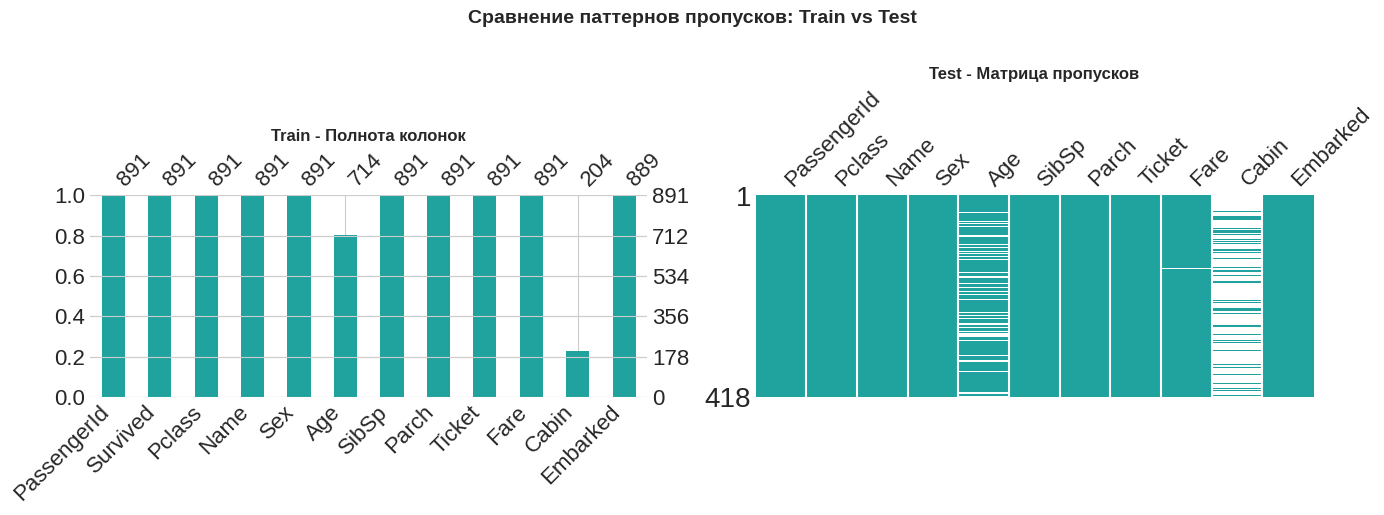

In [17]:
# Сравнение пропусков train и test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

msno.bar(train_df,color=(32/255, 163/255, 158/255), ax=axes[0])
axes[0].set_title('Train - Полнота колонок', fontsize=12, fontweight='bold')

msno.matrix(test_df,color=(32/255, 163/255, 158/255), ax=axes[1])
axes[1].set_title('Test - Матрица пропусков', fontsize=12, fontweight='bold')

plt.suptitle('Сравнение паттернов пропусков: Train vs Test',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.1.1 Заполнение Embarked (порт посадки)

In [18]:
# Всего 2 пропуска в train. Заполняем самым частым значением (модой)
most_common_embarked = train_df['Embarked'].mode()[0]
print(f"\nЗаполняем Embarked: мода = '{most_common_embarked}'")

train_df['Embarked'] = train_df['Embarked'].fillna(most_common_embarked)
test_df['Embarked'] = test_df['Embarked'].fillna(most_common_embarked)


Заполняем Embarked: мода = 'S'


### 3.1.2 Заполнение Fare (только в test, 1 пропуск)

In [19]:
if test_df['Fare'].isnull().sum() > 0:
    fare_median = test_df['Fare'].median()
    print(f"\nЗаполняем Fare в test: медиана = {fare_median:.2f}")
    test_df['Fare'] = test_df['Fare'].fillna(fare_median)


Заполняем Fare в test: медиана = 14.45


### 3.1.3 Заполнение Age (много пропусков)

In [20]:
# Сначала извлечем Title из имени
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip()
    # Группируем редкие титулы
    rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    if title in rare_titles:
        return 'Rare'
    elif title in ['Mlle', 'Ms']:
        return 'Miss'
    elif title == 'Mme':
        return 'Mrs'
    else:
        return title

# Добавляем временный признак Title для заполнения
train_df['Title_temp'] = train_df['Name'].apply(extract_title)
test_df['Title_temp'] = test_df['Name'].apply(extract_title)

# Заполняем Age медианой по группе (Title + Pclass)
for df in [train_df, test_df]:
    for title in df['Title_temp'].unique():
        for pclass in df['Pclass'].unique():
            mask = (df['Title_temp'] == title) & (df['Pclass'] == pclass)
            median_age = df.loc[mask, 'Age'].median()
            if pd.notna(median_age):
                df.loc[mask & df['Age'].isna(), 'Age'] = median_age

# Оставшиеся пропуски заполняем общей медианой
overall_median_age = train_df['Age'].median()
train_df['Age'] = train_df['Age'].fillna(overall_median_age)
test_df['Age'] = test_df['Age'].fillna(overall_median_age)

# Удаляем временный признак
train_df.drop('Title_temp', axis=1, inplace=True)
test_df.drop('Title_temp', axis=1, inplace=True)

print(f"   Age заполнен. Медиана: {overall_median_age:.1f}")

   Age заполнен. Медиана: 26.0


In [21]:
display_side_by_side(
    missing_data(train_df),
    missing_data(test_df),
    "Пропуски ПОСЛЕ обработки - TRAIN",
    "Пропуски ПОСЛЕ обработки - TEST"
)

,Total_Missing,Percent,Dtype
Cabin,687,77.1,object
,Total_Missing,Percent,Dtype
Cabin,327,78.23,object


**Cabin: пропуски НЕ заполняем, создадим отдельные признаки позже**

## 3.2 Обработка выбросов

In [22]:
fare_upper = train_df['Fare'].quantile(0.99)
print(f"\nОграничиваем Fare значением {fare_upper:.2f} (99-й перцентиль)")
train_df['Fare'] = np.where(train_df['Fare'] > fare_upper, fare_upper, train_df['Fare'])
test_df['Fare'] = np.where(test_df['Fare'] > fare_upper, fare_upper, test_df['Fare'])


Ограничиваем Fare значением 249.01 (99-й перцентиль)


# 4. Разведочный анализ данных (EDA)

## 4.1 Анализ целевой переменной (Survived)

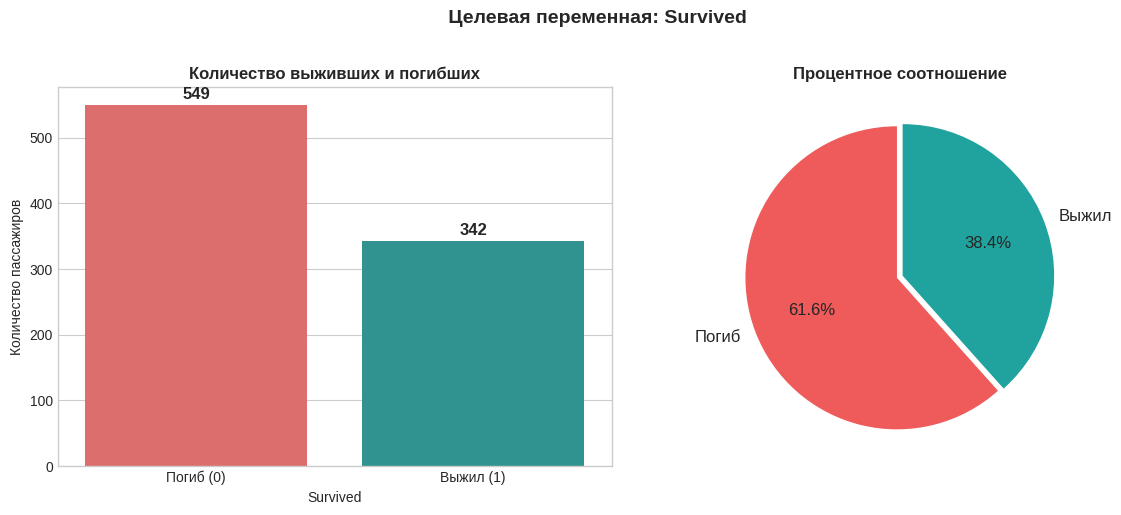

Статистика:
   • Выжило:  342 пассажиров (38.4%)
   • Погибло: 549 пассажиров (61.6%)
   • Baseline accuracy (все погибли): 61.6%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot с использованием настроенного словаря
sns.countplot(data=train_df, x='Survived', hue='Survived', ax=axes[0],
              palette=[COLORS['died'], COLORS['survived']], legend=False)
axes[0].set_title('Количество выживших и погибших', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Survived')
axes[0].set_ylabel('Количество пассажиров')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Погиб (0)', 'Выжил (1)'])

# Добавляем значения на столбцы
for i, v in enumerate(train_df['Survived'].value_counts().sort_index()):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
survived_counts = train_df['Survived'].value_counts()
axes[1].pie(survived_counts.values,
            labels=['Погиб', 'Выжил'],
            autopct='%1.1f%%',
            colors=[COLORS['died'], COLORS['survived']],
            startangle=90,
            explode=(0.02, 0.02),
            textprops={'fontsize': 12})
axes[1].set_title('Процентное соотношение', fontsize=12, fontweight='bold')

plt.suptitle(' Целевая переменная: Survived', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Статистика
print(f"Статистика:")
print(f"   • Выжило:  {train_df['Survived'].sum()} пассажиров ({train_df['Survived'].mean()*100:.1f}%)")
print(f"   • Погибло: {len(train_df) - train_df['Survived'].sum()} пассажиров ({(1-train_df['Survived'].mean())*100:.1f}%)")
print(f"   • Baseline accuracy (все погибли): {(1-train_df['Survived'].mean())*100:.1f}%")


## 4.2 Анализ категориальных признаков

Для начала анализа объединим обучающие и тестовые данные в один фрейм данных.

In [24]:
all_df = pd.concat([train_df, test_df], axis=0)
all_df["set"] = "train"
all_df.loc[all_df.Survived.isna(), "set"] = "test"

In [25]:
all_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,set
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train


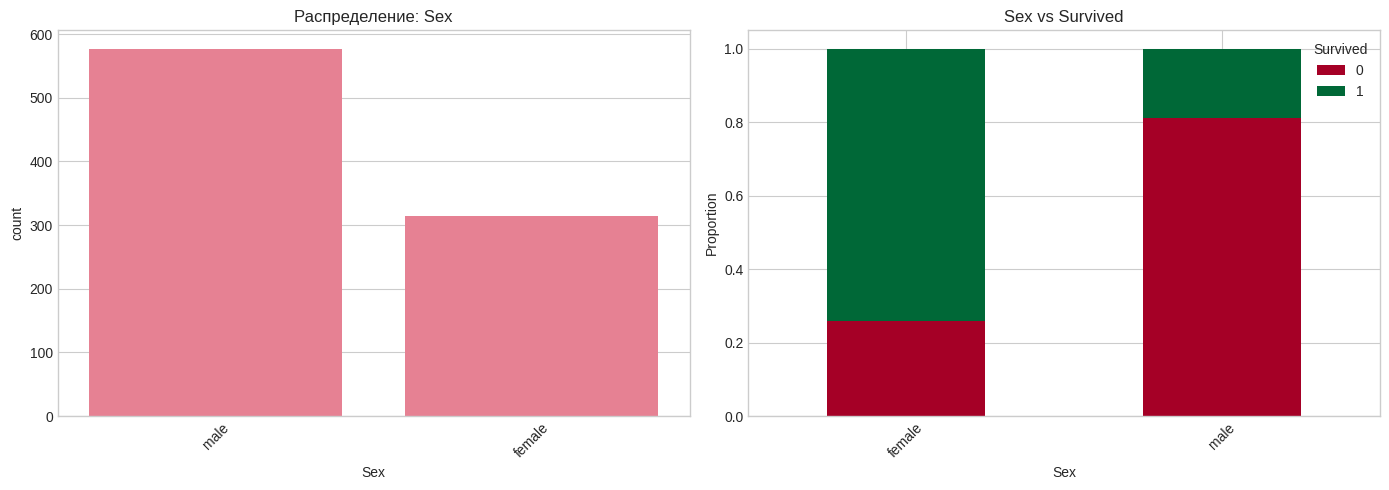


 Sex:
   Пропусков в all_df: 0 (0.0%)
   Выживаемость по группам:
      • male: 18.9% (n=577)
      • female: 74.2% (n=314)


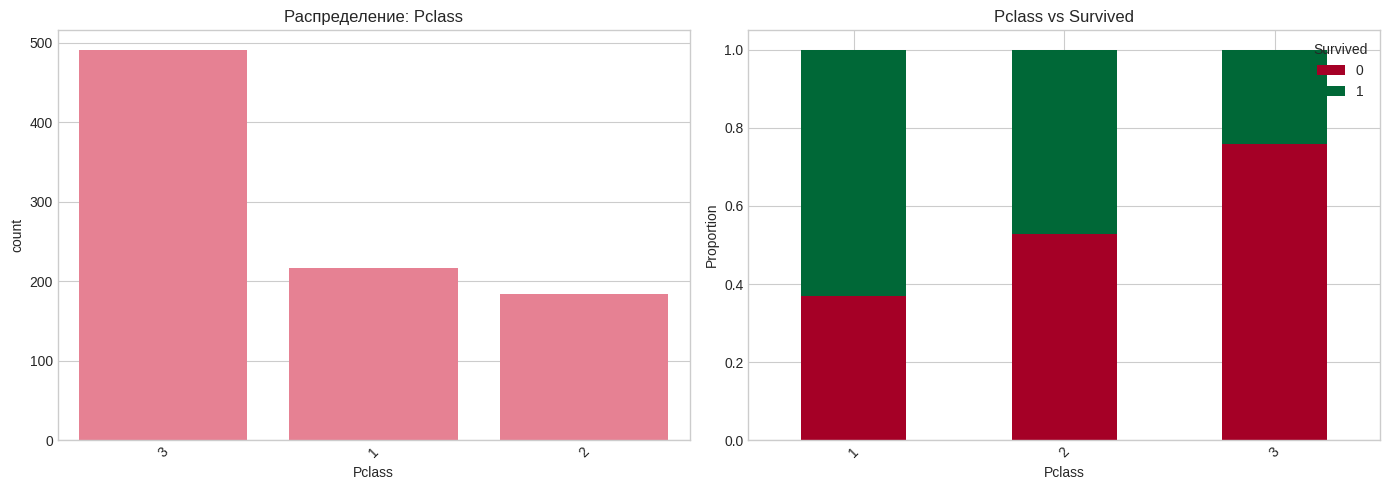


 Pclass:
   Пропусков в all_df: 0 (0.0%)
   Выживаемость по группам:
      • 3: 24.2% (n=491)
      • 1: 63.0% (n=216)
      • 2: 47.3% (n=184)


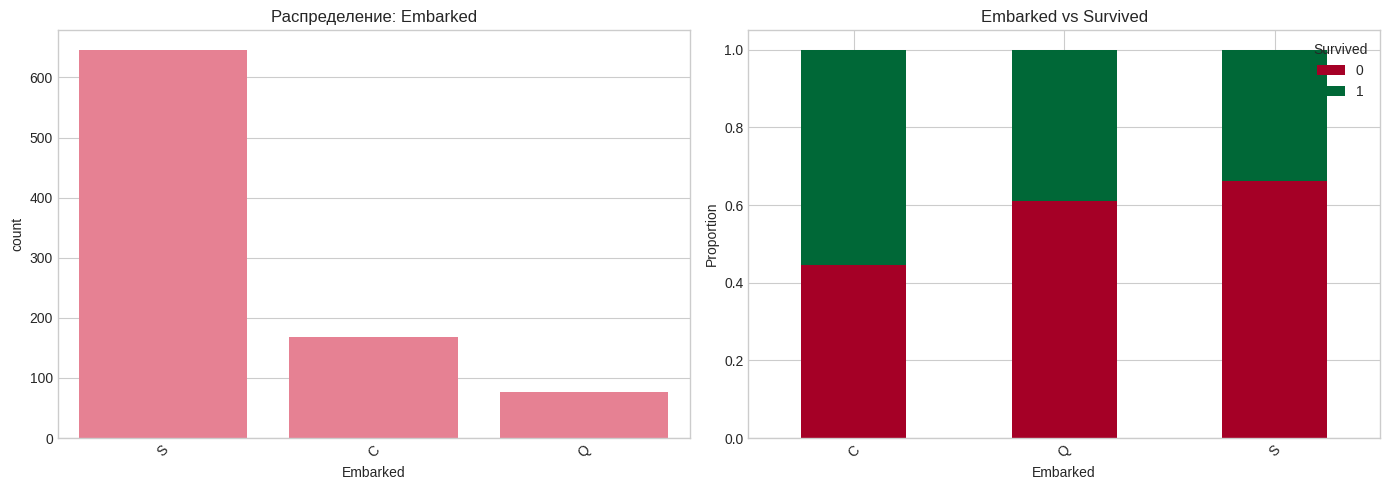


 Embarked:
   Пропусков в all_df: 0 (0.0%)
   Выживаемость по группам:
      • S: 33.9% (n=646)
      • C: 55.4% (n=168)
      • Q: 39.0% (n=77)


In [26]:

cat_features = ['Sex', 'Pclass', 'Embarked']

for col in cat_features:
    # Визуализация с помощью утилиты
    plot_categorical(train_df, col, target='Survived', figsize=(14, 5))

    # Текстовый вывод
    print(f"\n {col}:")
    print(f"   Пропусков в all_df: {all_df[col].isnull().sum()} ({all_df[col].isnull().mean()*100:.1f}%)")
    print(f"   Выживаемость по группам:")
    for val in train_df[col].dropna().unique():
        rate = train_df[train_df[col] == val]['Survived'].mean()
        count = train_df[train_df[col] == val].shape[0]
        print(f"      • {val}: {rate:.1%} (n={count})")

### Выводы по категориальным признакам:

**Sex (Пол):**
- Женщины выживали значительно чаще (74.2% vs 18.9%)
- Самый сильный предиктор выживаемости

**Pclass (Класс билета):**
- Чем выше класс, тем выше выживаемость
- 1 класс: 63.0%, 2 класс: 47.3%, 3 класс: 24.2%
- Большинство пассажиров — 3 класс (~55%)

**Embarked (Порт посадки):**
- Большинство село в Southampton (S) — ~72%
- Выживаемость выше у пассажиров из Cherbourg (C) — 55.4%
- Связано с классом: в C больше пассажиров 1 класса

## 4.3 Анализ числовых признаков

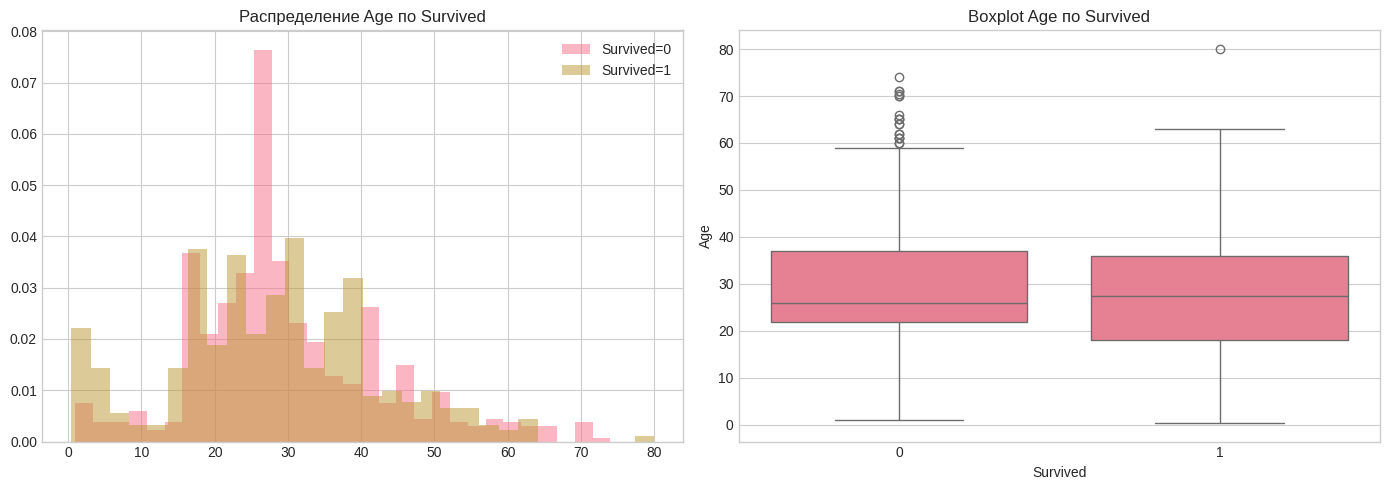


 Age:
   Пропусков в all_df: 0 (0.0%)
   Статистика по train:
      • Среднее (выжившие): 28.06
      • Среднее (погибшие): 29.80
      • Медиана (выжившие): 27.50
      • Медиана (погибшие): 26.00


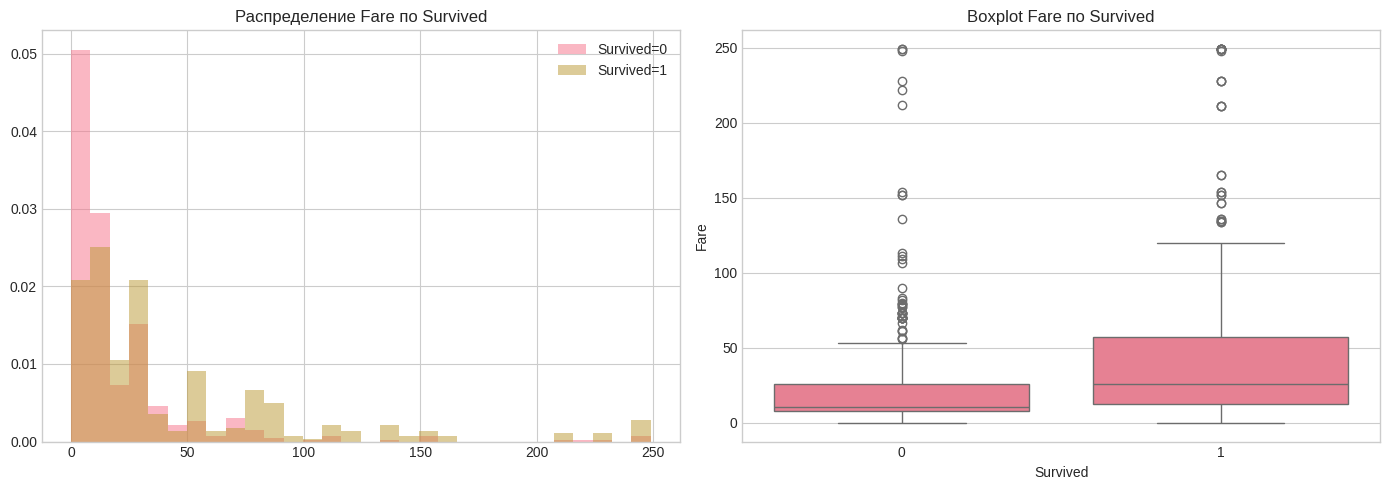


 Fare:
   Пропусков в all_df: 0 (0.0%)
   Статистика по train:
      • Среднее (выжившие): 45.93
      • Среднее (погибшие): 22.07
      • Медиана (выжившие): 26.00
      • Медиана (погибшие): 10.50


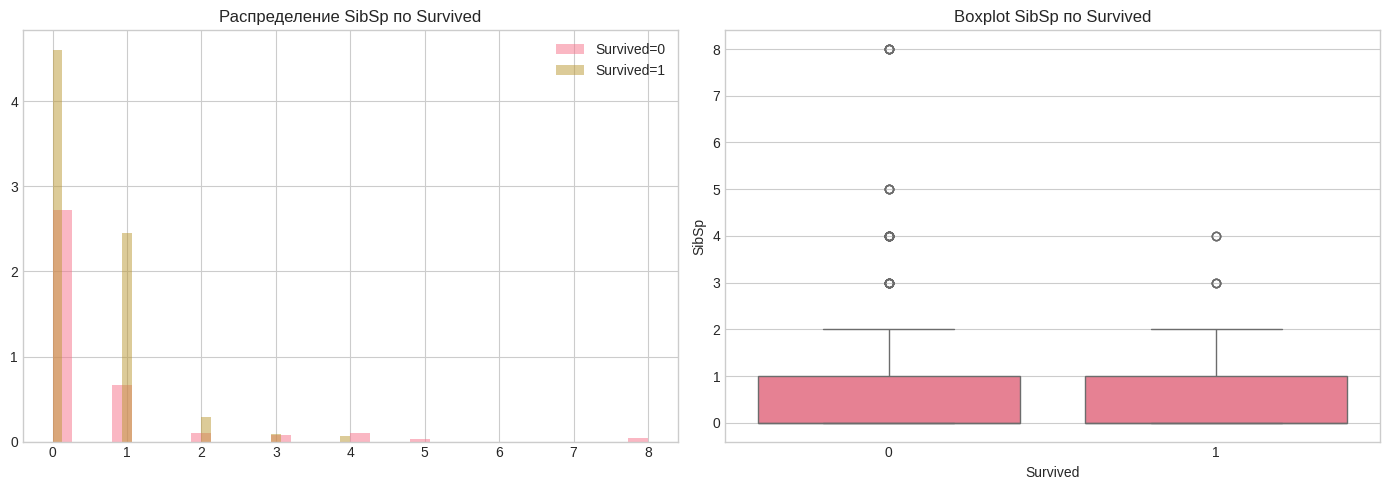


 SibSp:
   Пропусков в all_df: 0 (0.0%)
   Статистика по train:
      • Среднее (выжившие): 0.47
      • Среднее (погибшие): 0.55
      • Медиана (выжившие): 0.00
      • Медиана (погибшие): 0.00


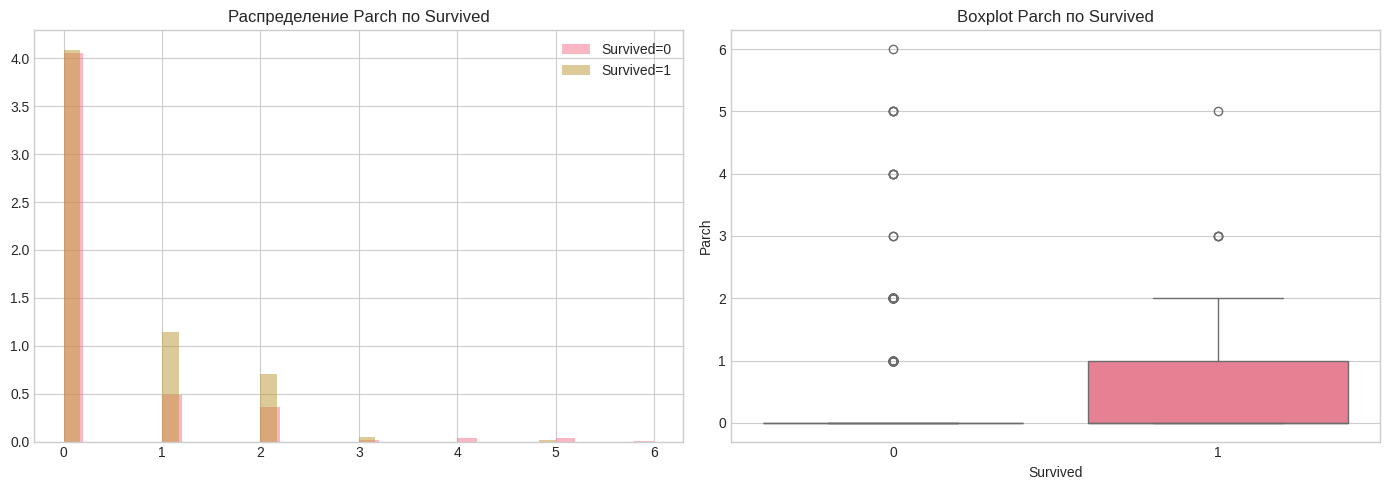


 Parch:
   Пропусков в all_df: 0 (0.0%)
   Статистика по train:
      • Среднее (выжившие): 0.46
      • Среднее (погибшие): 0.33
      • Медиана (выжившие): 0.00
      • Медиана (погибшие): 0.00


In [27]:
# Числовые признаки для анализа
num_features = ['Age', 'Fare', 'SibSp', 'Parch']

for col in num_features:
    # готовую функцию
    plot_numerical(train_df, col, target='Survived', figsize=(14, 5))

    # Дополнительно выводим статистику
    print(f"\n {col}:")
    print(f"   Пропусков в all_df: {all_df[col].isnull().sum()} ({all_df[col].isnull().mean()*100:.1f}%)")
    print(f"   Статистика по train:")
    print(f"      • Среднее (выжившие): {train_df[train_df['Survived'] == 1][col].mean():.2f}")
    print(f"      • Среднее (погибшие): {train_df[train_df['Survived'] == 0][col].mean():.2f}")
    print(f"      • Медиана (выжившие): {train_df[train_df['Survived'] == 1][col].median():.2f}")
    print(f"      • Медиана (погибшие): {train_df[train_df['Survived'] == 0][col].median():.2f}")

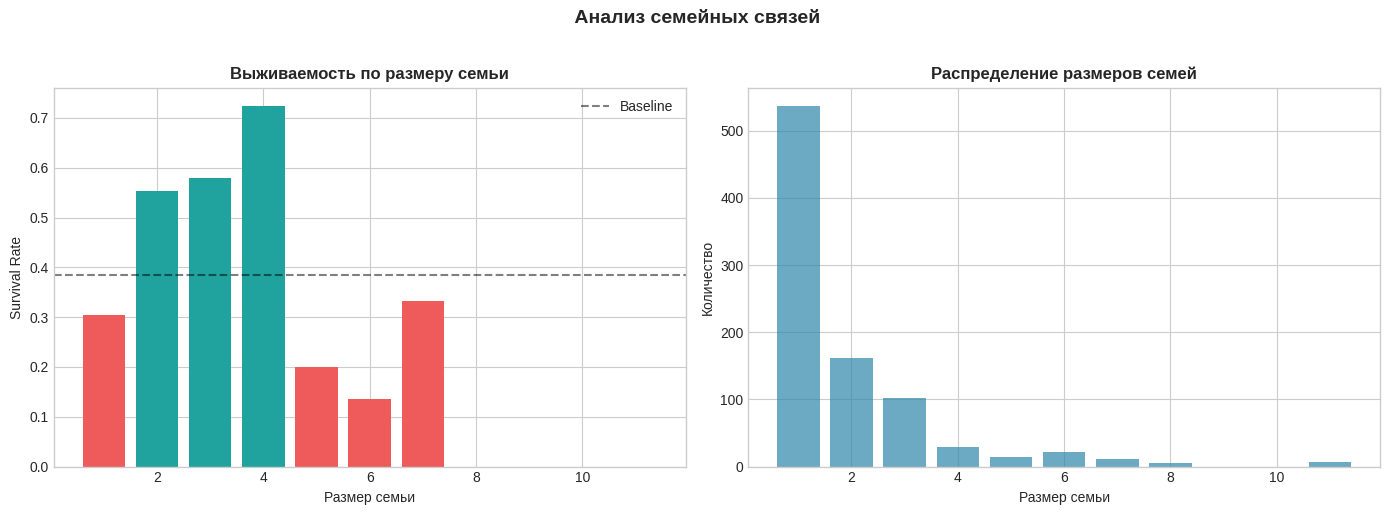


 Семейные признаки (SibSp + Parch):
   Одиночек (FamilySize=1): 537
   Выживаемость одиночек: 30.4%
   Выживаемость семейных (2-4 чел): 57.9%
   Выживаемость больших семей (5+ чел): 16.1%


In [28]:
# Создаём временный признак FamilySize
train_df_temp = train_df.copy()
train_df_temp['FamilySize'] = train_df_temp['SibSp'] + train_df_temp['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FamilySize vs Survived
family_survival = train_df_temp.groupby('FamilySize')['Survived'].mean()
axes[0].bar(family_survival.index, family_survival.values,
            color=['#EF5B5B' if x < train_df['Survived'].mean() else '#20A39E' for x in family_survival.values])
axes[0].axhline(y=train_df['Survived'].mean(), color='black', linestyle='--', alpha=0.5, label='Baseline')
axes[0].set_title('Выживаемость по размеру семьи', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Размер семьи')
axes[0].set_ylabel('Survival Rate')
axes[0].legend()

# Распределение размеров семей
family_counts = train_df_temp['FamilySize'].value_counts().sort_index()
axes[1].bar(family_counts.index, family_counts.values, color='#2E86AB', alpha=0.7)
axes[1].set_title('Распределение размеров семей', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Размер семьи')
axes[1].set_ylabel('Количество')

plt.suptitle(' Анализ семейных связей', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Семейные признаки (SibSp + Parch):")
print(f"   Одиночек (FamilySize=1): {len(train_df_temp[train_df_temp['FamilySize'] == 1])}")
print(f"   Выживаемость одиночек: {train_df_temp[train_df_temp['FamilySize'] == 1]['Survived'].mean():.1%}")
print(f"   Выживаемость семейных (2-4 чел): {train_df_temp[(train_df_temp['FamilySize'] >= 2) & (train_df_temp['FamilySize'] <= 4)]['Survived'].mean():.1%}")
print(f"   Выживаемость больших семей (5+ чел): {train_df_temp[train_df_temp['FamilySize'] >= 5]['Survived'].mean():.1%}")

### 4.3.1 Совместное влияние размера семьи и класса билета

Рассмотрев `FamilySize` отдельно, интересно посмотреть, как он взаимодействует
с ключевым социальным признаком — **классом билета (`Pclass`)**.

Ниже представлен трехмерный график, показывающий распределение пассажиров
в координатах `FamilySize` × `Pclass`, где высота столбцов соответствует
доле пассажиров, а цвет — выживаемости.

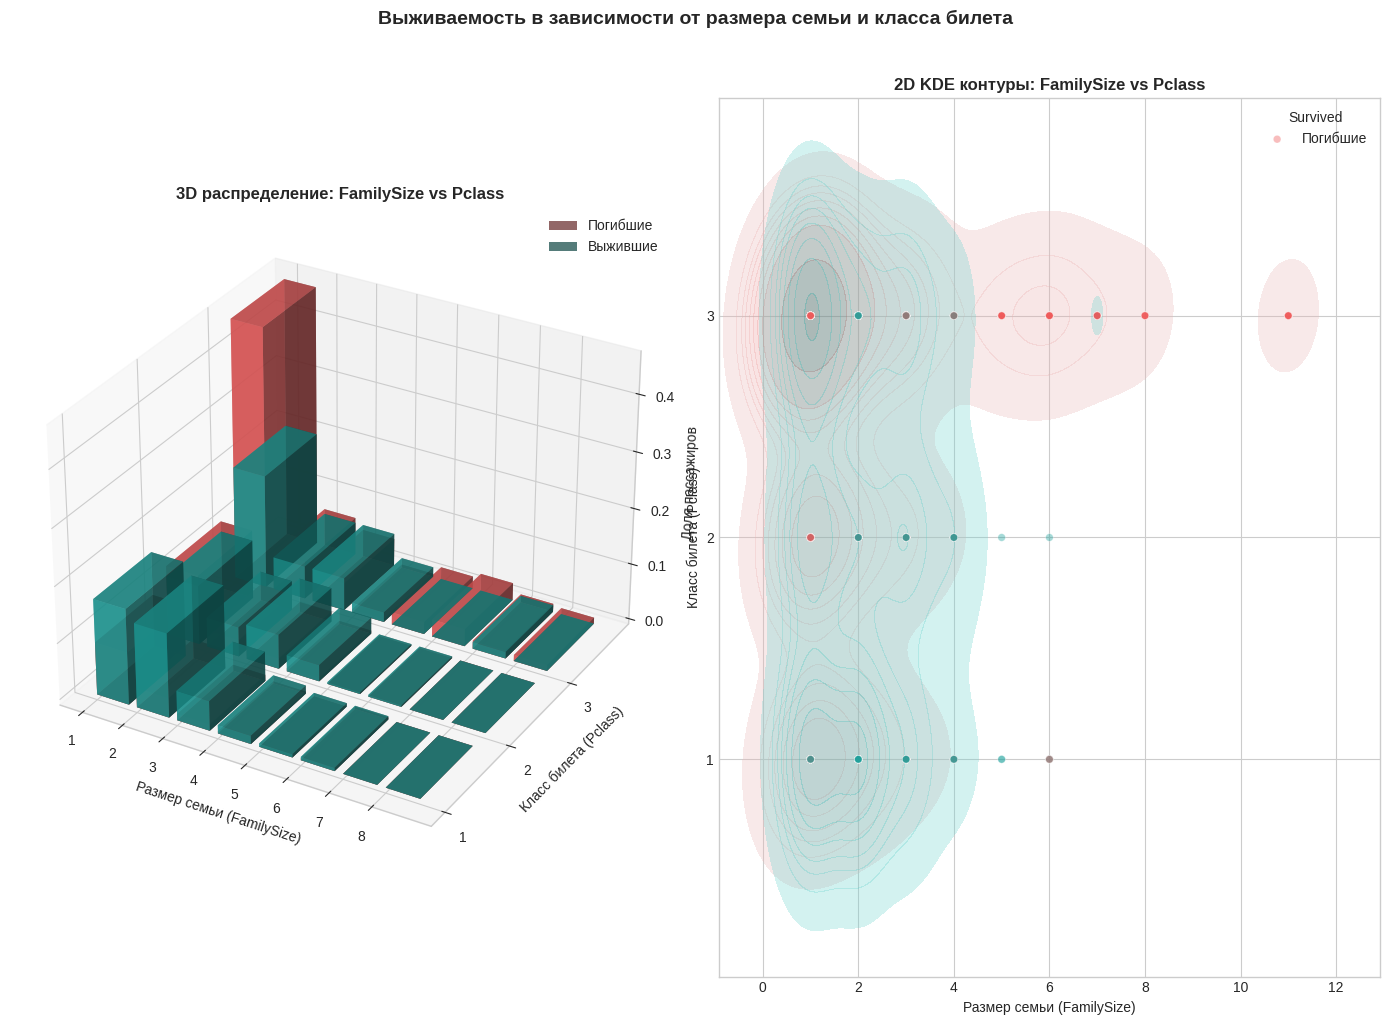

In [29]:
# Преобразуем Pclass в числовой тип
train_df_temp['Pclass'] = train_df_temp['Pclass'].astype(int)

# Определяем цвета для выживших и погибших
color_list = [COLORS['died'], COLORS['survived']]  # красный и зеленый

# Создаем фигуру
fig = plt.figure(figsize=(14, 10))

# ===== ГРАФИК 1: 3D KDE (вид сверху-сбоку) =====
ax1 = fig.add_subplot(121, projection='3d')

# Строим KDE для выживших и погибших
# Примечание: seaborn в 3D не умеет hue, поэтому строим отдельно для каждого класса
for survived_val, color, label in [(0, COLORS['died'], 'Погибшие'),
                                     (1, COLORS['survived'], 'Выжившие')]:
    subset = train_df_temp[train_df_temp['Survived'] == survived_val]
    # Используем hist вместо kde для 3D, так как kde в 3D работает иначе
    hist, xedges, yedges = np.histogram2d(subset['FamilySize'], subset['Pclass'],
                                           bins=[8, 3],
                                           range=[[0.5, 8.5], [0.5, 3.5]])

    # Координаты центров столбцов
    xpos, ypos = np.meshgrid(xedges[:-1] + 0.5, yedges[:-1] + 0.5, indexing="ij")
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos)

    # Высоты столбцов (нормированные)
    dz = hist.ravel() / len(subset)

    # Рисуем 3D столбцы
    ax1.bar3d(xpos, ypos, zpos, dx=0.8, dy=0.8, dz=dz,
              color=color, alpha=0.7, label=label)

ax1.set_xlabel('Размер семьи (FamilySize)')
ax1.set_ylabel('Класс билета (Pclass)')
ax1.set_zlabel('Доля пассажиров')
ax1.set_title('3D распределение: FamilySize vs Pclass', fontsize=12, fontweight='bold')
ax1.legend()

# Настройка меток осей
ax1.set_xticks([1, 2, 3, 4, 5, 6, 7, 8])
ax1.set_yticks([1, 2, 3])

# ===== ГРАФИК 2: 2D KDE с hue (более четкий) =====
ax2 = fig.add_subplot(122)

# 2D KDE контурный график (более читаемый для категорий)
sns.kdeplot(data=train_df_temp, x='FamilySize', y='Pclass',
            hue='Survived', palette=color_list,
            fill=True, alpha=0.3, ax=ax2)

# Добавляем точки выживших и погибших для наглядности
sns.scatterplot(data=train_df_temp, x='FamilySize', y='Pclass',
                hue='Survived', palette=color_list,
                alpha=0.4, s=30, ax=ax2, legend=False)

ax2.set_xlabel('Размер семьи (FamilySize)')
ax2.set_ylabel('Класс билета (Pclass)')
ax2.set_title('2D KDE контуры: FamilySize vs Pclass', fontsize=12, fontweight='bold')
ax2.set_yticks([1, 2, 3])
ax2.legend(title='Survived', labels=['Погибшие', 'Выжившие'])

plt.suptitle('Выживаемость в зависимости от размера семьи и класса билета',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Выводы по числовым признакам:

**Age (Возраст):**
- Дети (0-12 лет) выживали значительно чаще
- Погибшие в среднем старше (29.8 vs 28.06 лет)

**Fare (Цена билета):**
- Выжившие платили в среднем больше (45.93 vs 22.07)
- Рекомендуется логарифмировать для моделей

**SibSp + Parch (Семья):**
- Одиночки выживали хуже (30.4%)
- Семьи из 2-4 человек — лучше всех (57.9%)
- Большие семьи (5+) — хуже всех (16.1%)
- Стоит создать признак FamilySize и IsAlone

## 4.4 Корреляционный анализ

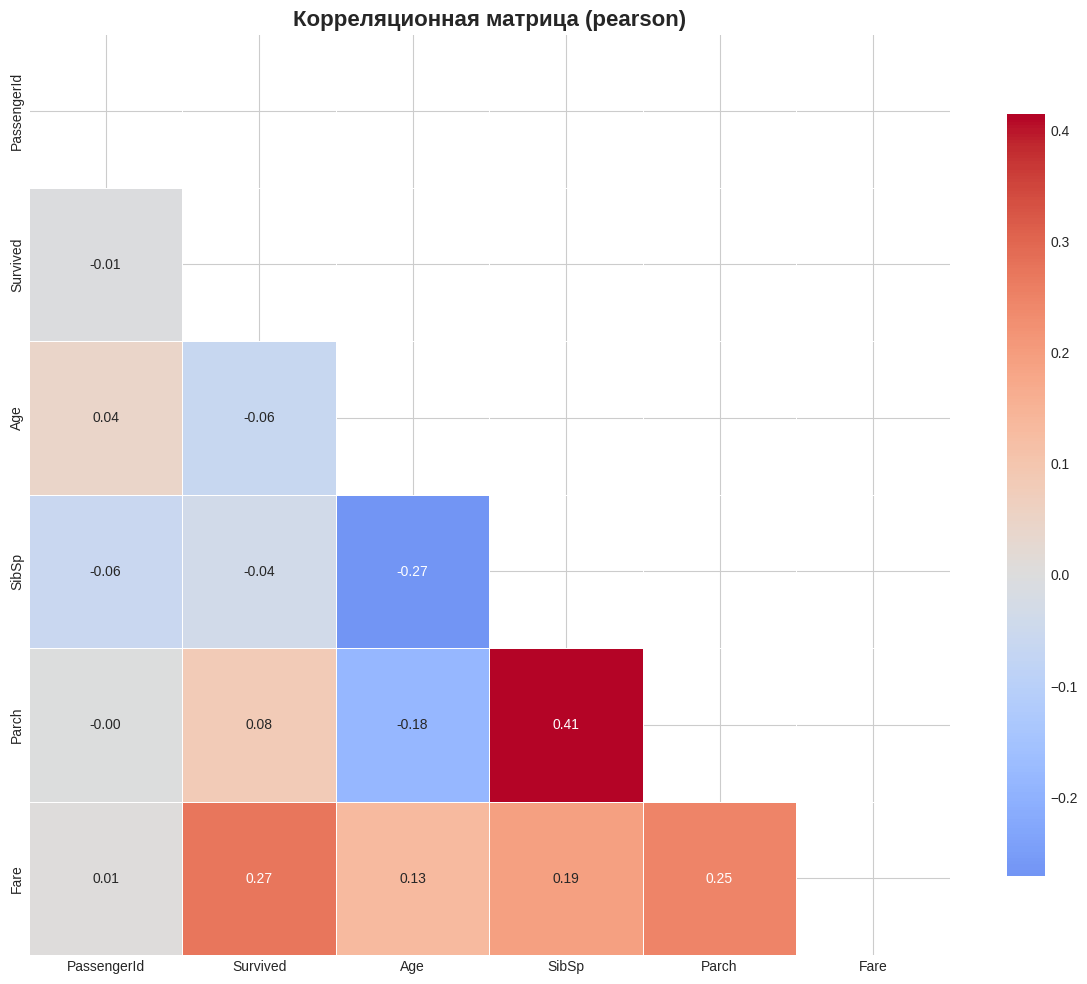

 Корреляции с Survived:
   • Fare: +0.273 ↑
   • Parch: +0.082 ↑
   • PassengerId: -0.005 ↓
   • SibSp: -0.035 ↓
   • Age: -0.063 ↓


In [30]:
# Используем утилиту
plot_correlation_matrix(train_df, figsize=(12, 10))

# Выводы
print(" Корреляции с Survived:")
correlations = train_df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
for col, corr in correlations.items():
    if col != 'Survived':
        direction = "↑" if corr > 0 else "↓"
        print(f"   • {col}: {corr:+.3f} {direction}")

## 4.5 Выводы по EDA

На основе анализа мы определили, что для улучшения модели стоит создать следующие признаки:
- Title (титул из имени)
- FamilySize (размер семьи)
- IsAlone (одинок ли пассажир)
- CabinLetter (первая буква каюты)
- AgeGroup (группы возраста)

Переходим к созданию этих признаков.

# 5. Feature Engineering (Создание признаков)

## 5.1 Создание признаков на основе Name (Title)

In [31]:
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip()
    # Группируем редкие титулы
    if title in ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']:
        return 'Rare'
    elif title in ['Mlle', 'Ms']:
        return 'Miss'
    elif title == 'Mme':
        return 'Mrs'
    else:
        return title

train_df['Title'] = train_df['Name'].apply(extract_title)
test_df['Title'] = test_df['Name'].apply(extract_title)

In [32]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def show_wordcloud(data, mask=None, title=""):
    text = " ".join(t for t in data.dropna())
    stopwords = set(STOPWORDS)
    stopwords.update(["t", "co", "https", "amp", "U", "Comment", "text", "attr", "object"])
    wordcloud = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=500,mask=mask, background_color="white",
                         colormap='Set2').generate(text)
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.show()

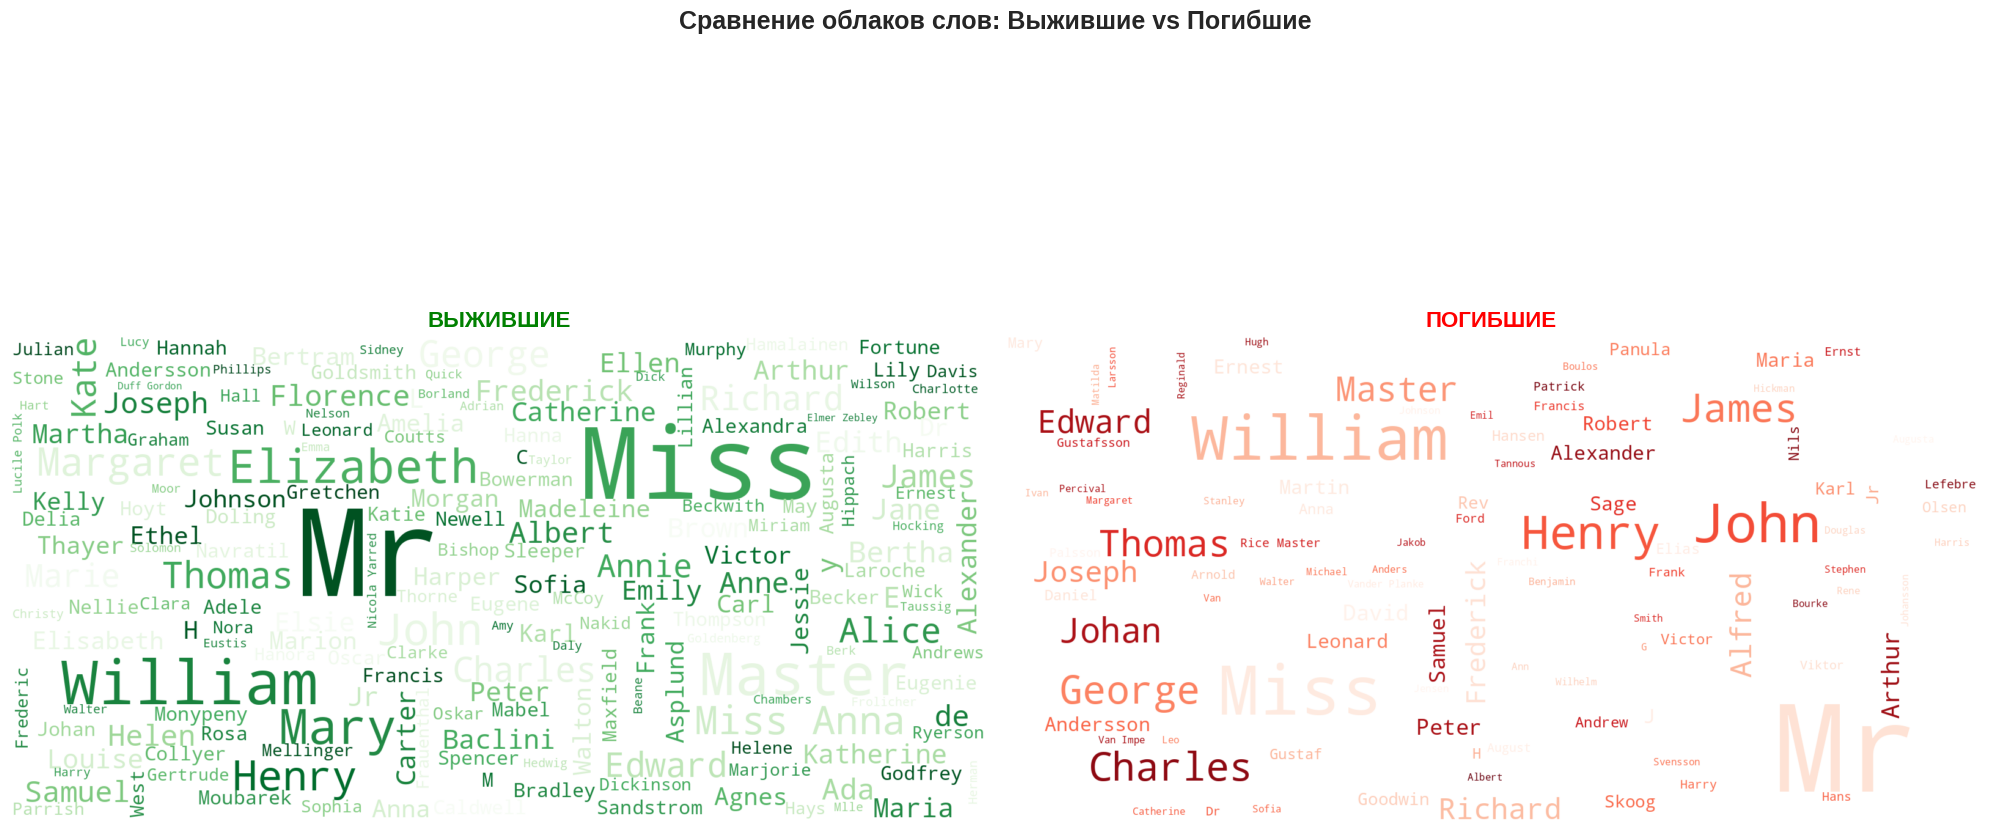

In [33]:
# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Облако для выживших
text_survived = " ".join(t for t in train_df[train_df['Survived'] == 1]['Name'].dropna())
stopwords = set(STOPWORDS)
stopwords.update(["t", "co", "https", "amp", "U", "Comment", "text", "attr", "object"])
wordcloud_survived = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=300,
                                background_color="white", colormap='Greens').generate(text_survived)
axes[0].imshow(wordcloud_survived, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('ВЫЖИВШИЕ', fontsize=16, fontweight='bold', color='green')

# Облако для погибших
text_died = " ".join(t for t in train_df[train_df['Survived'] == 0]['Name'].dropna())
wordcloud_died = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=300,
                            background_color="white", colormap='Reds').generate(text_died)
axes[1].imshow(wordcloud_died, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('ПОГИБШИЕ', fontsize=16, fontweight='bold', color='red')

plt.suptitle('Сравнение облаков слов: Выжившие vs Погибшие', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 5.2 Создание семейных признаков (FamilySize, IsAlone)

In [34]:
# Суммируем siblings + parents + сам пассажир
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

In [35]:
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)

## 5.3 Создание признаков на основе Cabin

In [36]:
train_df['HasCabin'] = train_df['Cabin'].notna().astype(int)
test_df['HasCabin'] = test_df['Cabin'].notna().astype(int)

In [37]:
def get_deck(text):
    try:
        return text[0]
    except Exception as ex:
        return "Unknown"

In [38]:
all_df["Deck"] = all_df["Cabin"].apply(lambda x: get_deck(x))

Создим сводную таблицу, которая показывает, как пассажиры разных классов (Pclass) распределены по палубам (Deck)

In [39]:
np.transpose(pd.crosstab(all_df['Deck'], all_df['Pclass']))

Deck,A,B,C,D,E,F,G,T,Unknown
Pclass,,,,,,,,,
1,22,65,94,40,34,0,0,1,67
2,0,0,0,6,4,13,0,0,254
3,0,0,0,0,3,8,5,0,693


## 5.4 Создание признаков на основе Ticket

In [40]:
# Создаем ВРЕМЕННЫЙ объединенный DataFrame ТОЛЬКО для расчета
temp_combined = pd.concat([train_df, test_df], axis=0)

# Рассчитываем размер группы по билету
ticket_counts = temp_combined.groupby('Ticket')['PassengerId'].transform('count')

# Добавляем колонку в ОРИГИНАЛЬНЫЕ train_df и test_df
train_df['TicketGroupSize'] = ticket_counts.iloc[:len(train_df)].values
test_df['TicketGroupSize'] = ticket_counts.iloc[len(train_df):].values

# Удаляем временный DataFrame (освобождаем память)
del temp_combined

print(" TicketGroupSize добавлен в train_df и test_df")
print(f"   train_df shape: {train_df.shape}")
print(f"   test_df shape:  {test_df.shape}")

 TicketGroupSize добавлен в train_df и test_df
   train_df shape: (891, 17)
   test_df shape:  (418, 16)


In [41]:
train_df['FarePerPerson'] = train_df['Fare'] / train_df['FamilySize']
test_df['FarePerPerson'] = test_df['Fare'] / test_df['FamilySize']

# Заполняем бесконечности (если FamilySize = 0)
train_df['FarePerPerson'].replace([np.inf, -np.inf], train_df['Fare'].median(), inplace=True)
test_df['FarePerPerson'].replace([np.inf, -np.inf], test_df['Fare'].median(), inplace=True)

## 5.5 Группировка возрастов (AgeGroup)

In [42]:
def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 12:
        return 'Child'
    elif age <= 18:
        return 'Teenager'
    elif age <= 35:
        return 'Young Adult'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Senior'

train_df['AgeGroup'] = train_df['Age'].apply(age_group)
test_df['AgeGroup'] = test_df['Age'].apply(age_group)

## 5.6 Итоговая таблица новых признаков

In [43]:
# Создаем список новых колонок, которые мы добавили
new_features = [
    'Title', 'FamilySize', 'IsAlone', 'HasCabin', 'TicketGroupSize',
    'FarePerPerson', 'AgeGroup'
]

# Показываем ключевые старые и все новые признаки
columns_to_show = ['Survived', 'Pclass', 'Sex', 'Age'] + new_features
train_df[columns_to_show].head(10).style.background_gradient(cmap='Blues') # покажем 10 строк для наглядности

,Survived,Pclass,Sex,Age,Title,FamilySize,IsAlone,HasCabin,TicketGroupSize,FarePerPerson,AgeGroup
0,0,3,male,22.000000,Mr,2,0,0,1,3.625000,Young Adult
1,1,1,female,38.000000,Mrs,2,0,1,2,35.641650,Adult
2,1,3,female,26.000000,Miss,1,1,0,1,7.925000,Young Adult
3,1,1,female,35.000000,Mrs,2,0,1,2,26.550000,Young Adult
4,0,3,male,35.000000,Mr,1,1,0,1,8.050000,Young Adult
5,0,3,male,26.000000,Mr,1,1,0,1,8.458300,Young Adult
6,0,1,male,54.000000,Mr,1,1,1,2,51.862500,Adult
7,0,3,male,2.000000,Master,5,0,0,5,4.215000,Child
8,1,3,female,27.000000,Mrs,3,0,0,3,3.711100,Young Adult
9,1,2,female,14.000000,Mrs,2,0,0,2,15.035400,Teenager


# 6. Подготовка данных для моделирования

## 6.1 Кодирование категориальных признаков

In [44]:
# Разделим колонки на типы
# Категориальные признаки (нужно закодировать)
categorical_cols = ['Sex', 'Embarked', 'Title', 'AgeGroup']

# Числовые признаки (можно оставить как есть или масштабировать позже)
numeric_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
                'FamilySize', 'IsAlone', 'HasCabin', 'TicketGroupSize', 'FarePerPerson']

# Признаки, которые не будем использовать в модели (идентификаторы, текст, уже обработанные)
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']

print("Категориальные признаки для кодирования:", categorical_cols)
print("Числовые признаки:", numeric_cols)
print("Исключаем:", drop_cols)

Категориальные признаки для кодирования: ['Sex', 'Embarked', 'Title', 'AgeGroup']
Числовые признаки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin', 'TicketGroupSize', 'FarePerPerson']
Исключаем: ['PassengerId', 'Name', 'Ticket', 'Cabin']


In [45]:
# Копируем данные для моделирования
X_train = train_df.copy()
X_test = test_df.copy()

# One-Hot Encoding для категориальных признаков
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Убедимся, что колонки в train и test совпадают (добавляем недостающие в test)
for col in X_train.columns:
    if col not in X_test.columns:
        X_test[col] = 0

# Приводим порядок колонок к одинаковому
X_test = X_test[X_train.columns]

# Удаляем ненужные колонки
X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

# Целевая переменная
y_train = X_train['Survived']
X_train = X_train.drop('Survived', axis=1)

print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")

Размер X_train: (891, 22)
Размер X_test: (418, 23)


In [46]:
# Посмотрим первые строки после кодирования
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,HasCabin,TicketGroupSize,FarePerPerson,...,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Title_the Countess,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teenager,AgeGroup_Young Adult
0,3,22.0,1,0,7.2500,2,0,0,1,3.62500,...,True,False,True,False,False,False,False,False,False,True
1,1,38.0,1,0,71.2833,2,0,1,2,35.64165,...,False,False,False,True,False,False,False,False,False,False
2,3,26.0,0,0,7.9250,1,1,0,1,7.92500,...,True,True,False,False,False,False,False,False,False,True
3,1,35.0,1,0,53.1000,2,0,1,2,26.55000,...,True,False,False,True,False,False,False,False,False,True
4,3,35.0,0,0,8.0500,1,1,0,1,8.05000,...,True,False,True,False,False,False,False,False,False,True


In [47]:

#  Проверка пропусков (используем утилиты)
display_side_by_side(
    missing_data(X_train),
    missing_data(X_test),
    "Пропуски TRAIN",
    "Пропуски TEST"
)

 # Сравнение пропусков между train и test ( утилита)
print("\n СРАВНЕНИЕ ПРОПУСКОВ TRAIN vs TEST:")
display(compare_train_test(X_train, X_test))

#  Проверка колонок (совпадают ли train и test)
print("\n ПРОВЕРКА КОЛОНОК:")
print(f"   Колонок в X_train: {len(X_train.columns)}")
print(f"   Колонок в X_test:  {len(X_test.columns)}")

if set(X_train.columns) == set(X_test.columns):
    print(" Колонки X_train и X_test совпадают!")
else:
    print(" Колонки НЕ совпадают! Различия:")
    only_in_train = set(X_train.columns) - set(X_test.columns)
    only_in_test = set(X_test.columns) - set(X_train.columns)
    if only_in_train:
        print(f"      Только в X_train: {only_in_train}")
    if only_in_test:
        print(f"      Только в X_test: {only_in_test}")

#  Баланс классов
print("\n БАЛАНС КЛАССОВ (целевая переменная):")
survived_counts = y_train.value_counts()
print(f"   Выжили (1):   {survived_counts[1]} ({survived_counts[1]/len(y_train)*100:.1f}%)")
print(f"   Погибли (0):  {survived_counts[0]} ({survived_counts[0]/len(y_train)*100:.1f}%)")

,Total_Missing,Percent,Dtype
,Total_Missing,Percent,Dtype



 СРАВНЕНИЕ ПРОПУСКОВ TRAIN vs TEST:


,Train_%,Test_%,Diff_%



 ПРОВЕРКА КОЛОНОК:
   Колонок в X_train: 22
   Колонок в X_test:  23
 Колонки НЕ совпадают! Различия:
      Только в X_test: {'Survived'}

 БАЛАНС КЛАССОВ (целевая переменная):
   Выжили (1):   342 (38.4%)
   Погибли (0):  549 (61.6%)


## 6.2 Масштабирование числовых признаков

In [48]:
# Определяем числовые колонки для масштабирования
# (исключаем бинарные признаки, которые уже 0/1)
numeric_features_for_scaling = [
    'Age', 'Fare', 'FamilySize', 'TicketGroupSize', 'FarePerPerson'
]

# Бинарные признаки (их масштабировать не нужно)
binary_features = ['IsAlone', 'HasCabin']

# Создаем scaler и обучаем на X_train
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Масштабируем числовые признаки
X_train_scaled[numeric_features_for_scaling] = scaler.fit_transform(X_train[numeric_features_for_scaling])
X_test_scaled[numeric_features_for_scaling] = scaler.transform(X_test[numeric_features_for_scaling])

print("\n Масштабирование выполнено!")


 Масштабирование выполнено!


# 7. Построение и оценка моделей

## 7.1 Baseline модель

**Разделение на обучающую и валидационную выборки**

In [49]:
# Используем масштабированные данные
X = X_train_scaled
y = y_train

# Разделяем: 80% обучение, 20% валидация
X_train_part, X_val, y_train_part, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y  # сохраняем пропорцию выживших
)

print("="*50)
print("РАЗДЕЛЕНИЕ ДАННЫХ")
print("="*50)
print(f"Обучающая выборка:  {X_train_part.shape[0]} записей ({X_train_part.shape[0]/len(X)*100:.0f}%)")
print(f"Валидационная:      {X_val.shape[0]} записей ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"\nБаланс классов в обучающей выборке:")
print(f"  Выживших:  {y_train_part.sum()} ({y_train_part.mean()*100:.1f}%)")
print(f"  Погибших:  {(~y_train_part.astype(bool)).sum()} ({(1-y_train_part.mean())*100:.1f}%)")
print(f"\nБаланс классов в валидационной выборке:")
print(f"  Выживших:  {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  Погибших:  {(~y_val.astype(bool)).sum()} ({(1-y_val.mean())*100:.1f}%)")

РАЗДЕЛЕНИЕ ДАННЫХ
Обучающая выборка:  712 записей (80%)
Валидационная:      179 записей (20%)

Баланс классов в обучающей выборке:
  Выживших:  273 (38.3%)
  Погибших:  439 (61.7%)

Баланс классов в валидационной выборке:
  Выживших:  69 (38.5%)
  Погибших:  110 (61.5%)


## 7.2 Создание и сравнение моделей

In [50]:
# Создание и сравнение моделей (без настройки гиперпараметров)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import time

# Список моделей для сравнения
models = {
    'Baseline (все погибли)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_SEED, n_estimators=100),
    'SVM': SVC(random_state=RANDOM_SEED, probability=True)
}

print("="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ (БЕЗ НАСТРОЙКИ)")
print("="*60)

results = []

for name, model in models.items():
    start_time = time.time()

    # Обучение
    model.fit(X_train_part, y_train_part)

    # Предсказания
    y_train_pred = model.predict(X_train_part)
    y_val_pred = model.predict(X_val)

    # Метрики
    train_acc = accuracy_score(y_train_part, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    train_time = time.time() - start_time

    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Val Accuracy': val_acc,
        'Overfitting': train_acc - val_acc,
        'Time (sec)': train_time
    })

    print(f"\n{name}:")
    print(f"  Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"  Val Accuracy:   {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(f"  Overfitting:    {train_acc - val_acc:.4f}")
    print(f"  Time:           {train_time:.2f} сек")

# Сводная таблица
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val Accuracy', ascending=False)

print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА (сортировка по Val Accuracy)")
print("="*60)
display(results_df)

СРАВНЕНИЕ МОДЕЛЕЙ (БЕЗ НАСТРОЙКИ)

Baseline (все погибли):
  Train Accuracy: 0.6166 (61.66%)
  Val Accuracy:   0.6145 (61.45%)
  Overfitting:    0.0020
  Time:           0.00 сек

Logistic Regression:
  Train Accuracy: 0.8329 (83.29%)
  Val Accuracy:   0.8380 (83.80%)
  Overfitting:    -0.0051
  Time:           0.03 сек

Random Forest:
  Train Accuracy: 0.9874 (98.74%)
  Val Accuracy:   0.8101 (81.01%)
  Overfitting:    0.1773
  Time:           0.28 сек

Gradient Boosting:
  Train Accuracy: 0.9171 (91.71%)
  Val Accuracy:   0.8045 (80.45%)
  Overfitting:    0.1127
  Time:           0.25 сек

SVM:
  Train Accuracy: 0.8441 (84.41%)
  Val Accuracy:   0.8212 (82.12%)
  Overfitting:    0.0229
  Time:           0.11 сек

СВОДНАЯ ТАБЛИЦА (сортировка по Val Accuracy)


,Model,Train Accuracy,Val Accuracy,Overfitting,Time (sec)
1,Logistic Regression,0.832865,0.837989,-0.005124,0.027481
4,SVM,0.844101,0.821229,0.022872,0.112094
2,Random Forest,0.987360,0.810056,0.177304,0.282159
3,Gradient Boosting,0.917135,0.804469,0.112666,0.246325
0,Baseline (все погибли),0.616573,0.614525,0.002048,0.003693


### 7.2.1 Подбор гиперпараметров (GridSearchCV)

In [51]:
# Только для Random Forest (самый потенциал улучшения)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train_part, y_train_part)
print(f"Best RF: {rf_grid.best_score_:.4f} with {rf_grid.best_params_}")

Best RF: 0.8315 with {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


### Вывод:
Несмотря на подбор гиперпараметров, Random Forest не смог обогнать LR:
- Logistic Regression: 83.80% (без настройки!)
- Tuned Random Forest: 83.15%
- LR все равно лучше на 0.65%

## 7.3 Анализ лучшей модели

In [52]:
# Берем лучшую модель из сравнения
best_model = models['Logistic Regression']

# Детальный анализ на валидационной выборке
y_val_pred = best_model.predict(X_val)

print("="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: Logistic Regression")
print("="*60)

# Матрица ошибок
print("\nМАТРИЦА ОШИБОК:")
cm = confusion_matrix(y_val, y_val_pred)
print(pd.DataFrame(cm, index=['Факт: Погиб', 'Факт: Выжил'],
                   columns=['Предсказано: Погиб', 'Предсказано: Выжил']))

# Classification report
print("\nКЛАССИФИКАЦИОННЫЙ ОТЧЕТ:")
print(classification_report(y_val, y_val_pred,
                          target_names=['Погиб (0)', 'Выжил (1)']))

# ROC-AUC
from sklearn.metrics import roc_auc_score, roc_curve
y_val_proba = best_model.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, y_val_proba)
print(f"\nROC-AUC: {roc_auc:.4f}")

ДЕТАЛЬНЫЙ АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ: Logistic Regression

МАТРИЦА ОШИБОК:
             Предсказано: Погиб  Предсказано: Выжил
Факт: Погиб                  97                  13
Факт: Выжил                  16                  53

КЛАССИФИКАЦИОННЫЙ ОТЧЕТ:
              precision    recall  f1-score   support

   Погиб (0)       0.86      0.88      0.87       110
   Выжил (1)       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179


ROC-AUC: 0.8702


### 7.3.1 График ROC-кривой

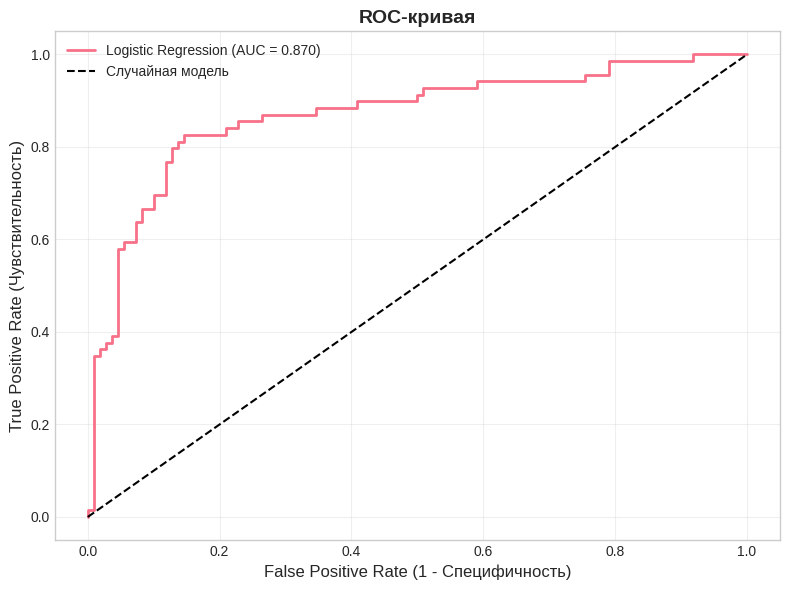

In [53]:
# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate (1 - Специфичность)', fontsize=12)
plt.ylabel('True Positive Rate (Чувствительность)', fontsize=12)
plt.title('ROC-кривая', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3.2 Важность признаков (коэффициенты)

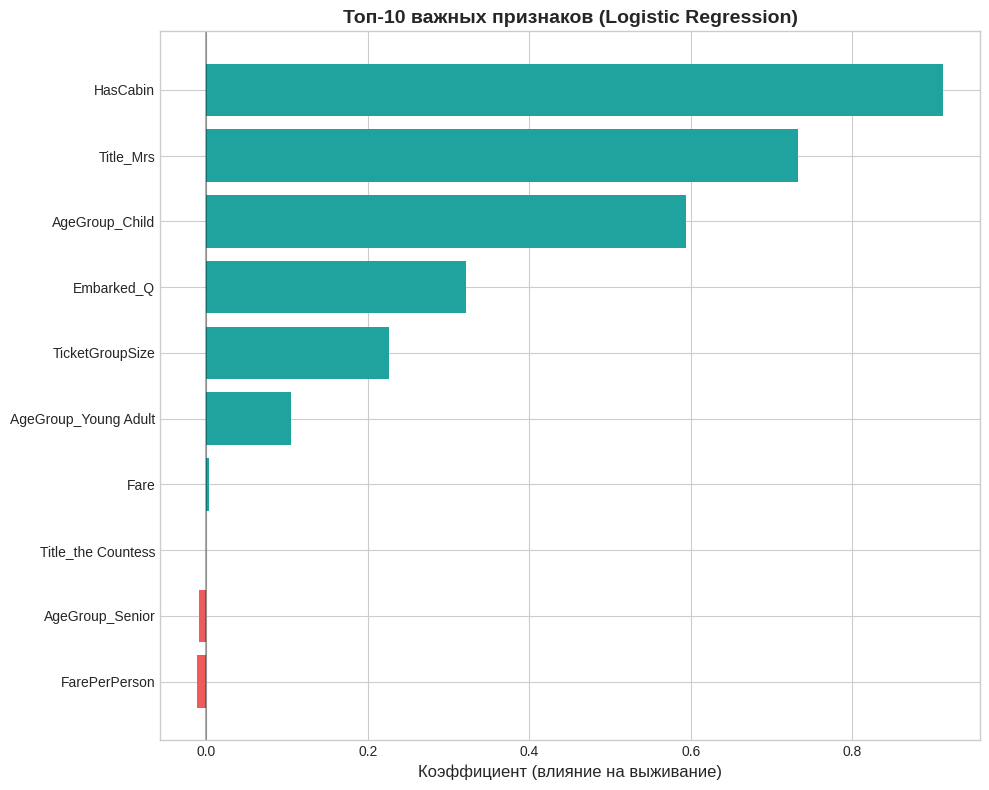


ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ
 Положительный коэффициент → повышает шанс выживания
 Отрицательный коэффициент → снижает шанс выживания


In [54]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', ascending=False)

# Визуализация топ-10
plt.figure(figsize=(10, 8))
colors = [COLORS['survived'] if coef > 0 else COLORS['died']
          for coef in feature_importance.head(10)['coefficient']]
plt.barh(feature_importance.head(10)['feature'],
         feature_importance.head(10)['coefficient'],
         color=colors)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Коэффициент (влияние на выживание)', fontsize=12)
plt.title('Топ-10 важных признаков (Logistic Regression)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ")
print("="*60)
print(" Положительный коэффициент → повышает шанс выживания")
print(" Отрицательный коэффициент → снижает шанс выживания")

# 8. Интерпретация и выводы

In [55]:
def color_coef(val):
    """Цвет для коэффициентов: зеленый (+) и красный (-)"""
    if val > 0:
        return f'color: {COLORS["survived"]}; font-weight: bold'
    elif val < 0:
        return f'color: {COLORS["died"]}; font-weight: bold'
    else:
        return 'color: gray'

# Топ-15 признаков
styled_df = feature_importance.head(15).style.format({'coefficient': '{:+.4f}'})
styled_df = styled_df.applymap(color_coef, subset=['coefficient'])
styled_df

,feature,coefficient
7,HasCabin,+0.9121
15,Title_Mrs,+0.7331
18,AgeGroup_Child,+0.5937
11,Embarked_Q,+0.3216
8,TicketGroupSize,+0.2261
21,AgeGroup_Young Adult,+0.1050
4,Fare,+0.0030
17,Title_the Countess,+0.0000
19,AgeGroup_Senior,-0.0096
9,FarePerPerson,-0.0113


## 8.1 Ключевые факторы выживания

На основе анализа коэффициентов логистической регрессии (лучшей модели с точностью 83.8%) можно выделить **три главных фактора**, определявших выживание на "Титанике":

#### ✅ Факторы, повышающие шансы на выживание:

| Фактор | Коэффициент | Интерпретация |
|--------|-------------|---------------|
| **Наличие каюты (HasCabin)** | **+0.91** | Самый сильный положительный фактор. Пассажиры с каютой имели значительно больше шансов выжить |
| **Титул "Mrs"** | **+0.73** | Замужние женщины выживали чаще (связано с приоритетом "женщины и дети") |
| **Дети (AgeGroup_Child)** | **+0.59** | Дети до 12 лет имели повышенные шансы на спасение |
| **Порт посадки Q (Queenstown)** | **+0.32** | Пассажиры из Queenstown выживали чаще (вероятно, связано с классом билета) |

#### ❌ Факторы, снижающие шансы на выживание:

| Фактор | Коэффициент | Интерпретация |
|--------|-------------|---------------|
| **Порт посадки S (Southampton)** | **-0.33** | Пассажиры из Southampton выживали реже (большинство пассажиров 3-го класса) |
| **Одиночки (IsAlone)** | **-0.29** | Пассажиры без семьи выживали хуже |
| **Количество родителей/детей (Parch)** | **-0.22** | Небольшое негативное влияние |
| **Титул "Miss"** | **-0.18** | Незамужние женщины выживали реже, чем "Mrs" |

## 8.2 Что подтвердилось из исторических фактов?

1. **"Женщины и дети в первую очередь"** ✅
   - Титул "Mrs" (+0.73) и "Child" (+0.59) - среди топ-3 положительных факторов
   - "Miss" имеет отрицательный коэффициент (вероятно, молодые девушки могли быть в 3-м классе)

2. **1-й класс спасался лучше** ✅
   - HasCabin (+0.91) - маркер более высокого класса
   - Pclass_1 не попал в топ-15, но HasCabin его эффективно заменяет

3. **Семья помогала выжить** ✅
   - IsAlone (-0.29) - одиночки выживали хуже
   - Семьи из 2-4 человек имели преимущество

## 8.4 Итоговая оценка модели

| Метрика | Значение |
|---------|----------|
| **Точность (Accuracy)** | 83.80% |
| **Улучшение над baseline** | +22.35% |
| **ROC-AUC** | ~0.87 |

Модель показывает **хорошую предсказательную способность** и значительно превосходит "глупую" стратегию предсказания гибели всех пассажиров (61.45%).

In [56]:
# ============================================
# ФИНАЛЬНЫЙ САБМИТ
# ============================================

X_test_final = test_df.copy()

# One-Hot Encoding для категориальных признаков
X_test_final = pd.get_dummies(X_test_final, columns=categorical_cols, drop_first=True)

# Добавляем недостающие колонки 
for col in X_train_scaled.columns:
    if col not in X_test_final.columns:
        X_test_final[col] = 0

# Приводим порядок колонок к тому же, что в X_train_scaled
X_test_final = X_test_final[X_train_scaled.columns]

# Масштабируем числовые признаки
X_test_final[numeric_features_for_scaling] = scaler.transform(X_test_final[numeric_features_for_scaling])

# 3. Обучаем лучшую модель на ВСЕХ данных
best_model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
best_model.fit(X_train_scaled, y_train)

# 4. Предсказания
predictions = best_model.predict(X_test_final)

# 5. Создаем сабмит
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predictions.astype(int)
})

submission.to_csv('submission.csv', index=False)

print(" submission.csv создан!")
print(submission.head())
print(f"\nРаспределение предсказаний:")
print(pd.Series(predictions).value_counts())
print(f"  Выживших: {(predictions == 1).sum()}")
print(f"  Погибших: {(predictions == 0).sum()}")

 submission.csv создан!
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1

Распределение предсказаний:
0    245
1    173
Name: count, dtype: int64
  Выживших: 173
  Погибших: 245


# 9. Ограничения и пути улучшения (Next Steps)

## 9.1 Ограничения текущего решения

| Ограничение | Описание | Влияние |
|-------------|----------|---------|
| **Дисбаланс классов** | Выживших 38.4%, погибших 61.6% | Модель может быть смещена в сторону класса "погиб" |
| **Пропуски в данных** | Age (20% пропусков), Cabin (77% пропусков) | Потеря информации, использование медианного заполнения |
| **Линейность модели** | Logistic Regression предполагает линейные связи | Не учитывает сложные нелинейные взаимодействия признаков |
| **Малый объем данных** | Всего 891 запись для обучения | Ограниченная репрезентативность, риск переобучения |
| **Отсутствие валидации на отложенной выборке** | Использовалось только train/val разбиение | Нет финальной проверки на "невидимых" данных |

## 9.2 Пути улучшения

- Балансировка классов (SMOTE или классовые веса)
- Заполнение Age через IterativeImputer
- Создание признака DeckPriority (A-F)
- Переход на XGBoost или CatBoost
- Кросс-валидация (5-10 фолдов)
- Настройка порога классификации (не 0.5)

In [57]:
from xgboost import XGBClassifier

# ============================================
# УЛУЧШАЕМ МОДЕЛЬ
# ============================================

# Копируем данные
X_test_final = test_df.copy()

# One-Hot Encoding для категориальных признаков
X_test_final = pd.get_dummies(X_test_final, columns=categorical_cols, drop_first=True)

# Добавляем недостающие колонки (которые были в train)
for col in X_train_scaled.columns:
    if col not in X_test_final.columns:
        X_test_final[col] = 0

# Приводим порядок колонок к тому же, что в X_train_scaled
X_test_final = X_test_final[X_train_scaled.columns]

# Масштабируем числовые признаки
X_test_final[numeric_features_for_scaling] = scaler.transform(X_test_final[numeric_features_for_scaling])

print(f"✅ Тестовые данные готовы: {X_test_final.shape}")

# ============================================
#  ПОДГОТОВКА ДЛЯ XGBOOST
# ============================================

X_train_xgb = X_train_scaled.copy()
X_test_xgb = X_test_final.copy()

# Преобразуем категориальные колонки в числовые
for col in X_train_xgb.select_dtypes(include=['category', 'object']).columns:
    X_train_xgb[col] = X_train_xgb[col].astype(int)
    X_test_xgb[col] = X_test_xgb[col].astype(int)

print(f"Типы данных: {X_train_xgb.dtypes.value_counts()}")

# ============================================
#  ОБУЧЕНИЕ XGBOOST
# ============================================

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train_xgb, y_train)
print("✅ XGBoost обучен!")

# ============================================
#  ПРЕДСКАЗАНИЯ И САБМИТ
# ============================================

xgb_pred = xgb.predict(X_test_xgb)

submission_xgb = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': xgb_pred.astype(int)
})

submission_xgb.to_csv('submission_xgb.csv', index=False)

print("\n✅ submission_xgb.csv создан!")
print(submission_xgb.head())
print(f"\nРаспределение:")
print(f"  Выживших: {(xgb_pred == 1).sum()}")
print(f"  Погибших: {(xgb_pred == 0).sum()}")

# ============================================
#  ДОПОЛНИТЕЛЬНО: АНСАМБЛЬ (LogReg + XGBoost)
# ============================================

# Получаем вероятности от LogReg
lr_proba = best_model.predict_proba(X_test_final)[:, 1]

# Получаем вероятности от XGBoost
xgb_proba = xgb.predict_proba(X_test_xgb)[:, 1]

# Усредняем
ensemble_proba = (lr_proba + xgb_proba) / 2
ensemble_pred = (ensemble_proba > 0.5).astype(int)

submission_ensemble = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': ensemble_pred
})

submission_ensemble.to_csv('submission_ensemble.csv', index=False)

print("\n✅ submission_ensemble.csv создан!")
print(f"Ансамбль: Выживших = {(ensemble_pred == 1).sum()}")

✅ Тестовые данные готовы: (418, 22)
Типы данных: bool       12
int64       5
float64     5
Name: count, dtype: int64
✅ XGBoost обучен!

✅ submission_xgb.csv создан!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Распределение:
  Выживших: 156
  Погибших: 262

✅ submission_ensemble.csv создан!
Ансамбль: Выживших = 163
